# 数据集加载及预处理

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
import numpy as np

# 加载加利福尼亚房价数据集
california_housing = fetch_california_housing(data_home='./data')
X, y = california_housing.data, california_housing.target

# 先划分数据集，然后在训练集上fit标准化器
from sklearn.model_selection import train_test_split

# 首先划分训练集和临时集（验证集+测试集）
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 再将临时集划分为验证集和测试集
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# 数据标准化（只对特征进行标准化，标签不进行标准化）
# 在训练集上fit_transform，验证集和测试集只进行transform
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

# 自定义Dataset类
class CaliforniaHousingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx].unsqueeze(0)

# 创建数据集
train_dataset = CaliforniaHousingDataset(X_train_scaled, y_train)
val_dataset = CaliforniaHousingDataset(X_val_scaled, y_val)
test_dataset = CaliforniaHousingDataset(X_test_scaled, y_test)

# 创建DataLoader
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"数据集大小: 总计 {len(X)}")
print(f"训练集: {len(train_dataset)} 样本")
print(f"验证集: {len(val_dataset)} 样本")
print(f"测试集: {len(test_dataset)} 样本")
print(f"特征维度: {X.shape[1]}")


数据集大小: 总计 20640
训练集: 14448 样本
验证集: 3096 样本
测试集: 3096 样本
特征维度: 8


In [3]:
for x,y in train_loader:
    print(x.shape)
    print(y.shape)
    break

torch.Size([64, 8])
torch.Size([64, 1])


In [4]:


# 演示批量情况
print(f"\n批量情况演示:")
y_batch = torch.tensor([1.2, 2.3, 3.4])  # 3个样本的标签
print(f"批量标签原始形状: {y_batch.shape}")
y_batch_unsqueezed = y_batch.unsqueeze(1)  # 在第1维增加维度
print(f"批量标签unsqueeze(1)后形状: {y_batch_unsqueezed.shape}")
print(f"批量标签内容:\n{y_batch_unsqueezed}")



批量情况演示:
批量标签原始形状: torch.Size([3])
批量标签unsqueeze(1)后形状: torch.Size([3, 1])
批量标签内容:
tensor([[1.2000],
        [2.3000],
        [3.4000]])


# 搭建模型

In [5]:
# 定义房价回归模型，并添加详细注释
class HousePriceModel(nn.Module):
    def __init__(self, input_size, hidden_size=30, output_size=1):
        """
        input_size: 输入特征维度
        hidden_size: 隐藏层神经元个数
        output_size: 输出层神经元个数（回归问题通常为1）
        """
        super(HousePriceModel, self).__init__()
        # 第一层：全连接层，将输入特征input_size映射到hidden_size
        self.fc1 = nn.Linear(input_size, hidden_size)
        # 激活函数：ReLU 非线性激活
        self.relu = nn.ReLU()
        # 第二层：全连接层，将hidden_size映射到输出output_size
        self.fc2 = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        """
        前向传播过程
        x: 输入特征张量，形状为(batch_size, input_size)
        返回值: 模型输出，形状为(batch_size, output_size)
        """
        # 输入通过第一层全连接
        x = self.fc1(x)
        # 经过ReLU激活函数
        x = self.relu(x)
        # 输入第二层全连接
        x = self.fc2(x)
        # 返回最终输出（预测房价）
        return x

# 获取输入特征维度
input_size = X.shape[1]  # 特征维度

# 创建房价预测模型实例
# input_size: 输入特征维度
# hidden_size: 隐藏层神经元数，这里设为30
# output_size: 输出维度回归只需1（预测房价）
model = HousePriceModel(input_size=input_size, hidden_size=30, output_size=1)

# 打印模型结构，方便查看层次
print(f"模型结构:")
print(model)

# 打印模型参数总数量（所有可训练参数的个数）
print(f"\n模型参数数量: {sum(p.numel() for p in model.parameters())}")


模型结构:
HousePriceModel(
  (fc1): Linear(in_features=8, out_features=30, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=30, out_features=1, bias=True)
)

模型参数数量: 301


使用设备: cpu
开始训练...
[Step 50] Val Loss: 0.8938
[Step 100] Val Loss: 0.6521
[Step 150] Val Loss: 0.6057
[Step 200] Val Loss: 0.5888
Epoch [1/100]  Train Loss: 1.0181
[Step 250] Val Loss: 0.5745
[Step 300] Val Loss: 0.5601
[Step 350] Val Loss: 0.5555
[Step 400] Val Loss: 0.5407
[Step 450] Val Loss: 0.5311
Epoch [2/100]  Train Loss: 0.5584
[Step 500] Val Loss: 0.5226
[Step 550] Val Loss: 0.5143
[Step 600] Val Loss: 0.5085
[Step 650] Val Loss: 0.5059
Epoch [3/100]  Train Loss: 0.5016
[Step 700] Val Loss: 0.5004
[Step 750] Val Loss: 0.4954
[Step 800] Val Loss: 0.4923
[Step 850] Val Loss: 0.4905
[Step 900] Val Loss: 0.4855
Epoch [4/100]  Train Loss: 0.4797
[Step 950] Val Loss: 0.4826
[Step 1000] Val Loss: 0.4794
[Step 1050] Val Loss: 0.4794
[Step 1100] Val Loss: 0.4775
Epoch [5/100]  Train Loss: 0.4661
[Step 1150] Val Loss: 0.4741
[Step 1200] Val Loss: 0.4733
[Step 1250] Val Loss: 0.4708
[Step 1300] Val Loss: 0.4682
[Step 1350] Val Loss: 0.4660
Epoch [6/100]  Train Loss: 0.4561
[Step 1400] Val

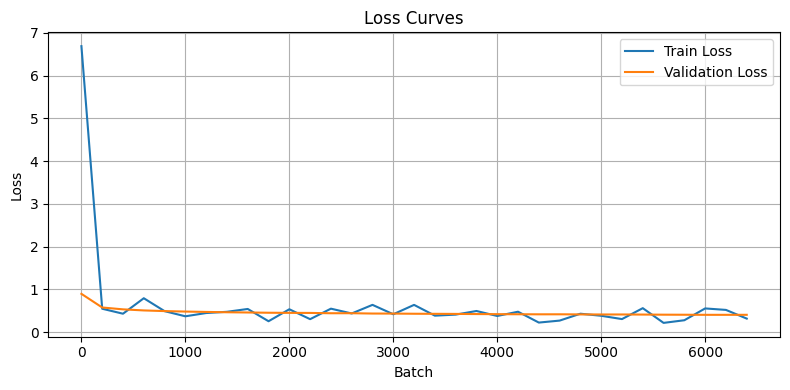

lr=0.01 测试集均方误差损失: 0.3690
开始训练...
[Step 50] Val Loss: 0.6736
[Step 100] Val Loss: 0.5971
[Step 150] Val Loss: 0.5448
[Step 200] Val Loss: 0.5194
Epoch [1/100]  Train Loss: 0.6938
[Step 250] Val Loss: 0.5082
[Step 300] Val Loss: 0.4992
[Step 350] Val Loss: 0.4868
[Step 400] Val Loss: 0.4959
[Step 450] Val Loss: 0.4847
Epoch [2/100]  Train Loss: 0.4869
[Step 500] Val Loss: 0.4793
[Step 550] Val Loss: 0.4758
[Step 600] Val Loss: 0.4689
[Step 650] Val Loss: 0.4667
Epoch [3/100]  Train Loss: 0.4606
[Step 700] Val Loss: 0.4778
[Step 750] Val Loss: 0.4644
[Step 800] Val Loss: 0.4621
[Step 850] Val Loss: 0.4599
[Step 900] Val Loss: 0.4531
Epoch [4/100]  Train Loss: 0.4477
[Step 950] Val Loss: 0.4488
[Step 1000] Val Loss: 0.4527
[Step 1050] Val Loss: 0.4498
[Step 1100] Val Loss: 0.4404
Epoch [5/100]  Train Loss: 0.4402
[Step 1150] Val Loss: 0.4419
[Step 1200] Val Loss: 0.4446
[Step 1250] Val Loss: 0.4373
[Step 1300] Val Loss: 0.4420
[Step 1350] Val Loss: 0.4343
Epoch [6/100]  Train Loss: 0.4339

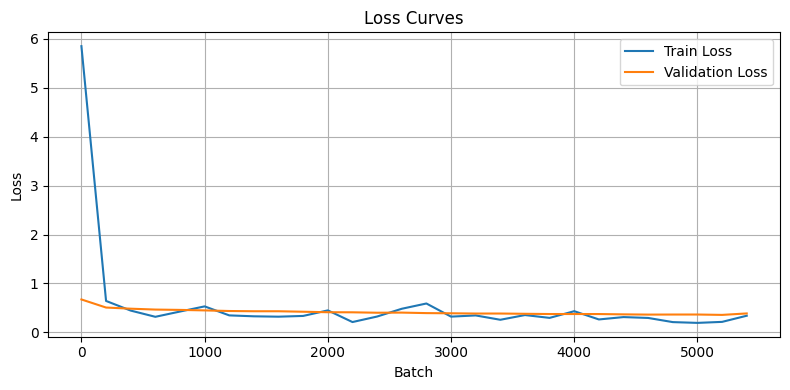

lr=0.03 测试集均方误差损失: 0.3303
开始训练...
[Step 50] Val Loss: 0.6249
[Step 100] Val Loss: 0.6018
[Step 150] Val Loss: nan
[Step 200] Val Loss: nan
Epoch [1/100]  Train Loss: nan
[Step 250] Val Loss: nan
[Step 300] Val Loss: nan
[Step 350] Val Loss: nan
[Step 400] Val Loss: nan
[Step 450] Val Loss: nan
Epoch [2/100]  Train Loss: nan
[Step 500] Val Loss: nan
[Step 550] Val Loss: nan
[Step 600] Val Loss: nan
Early stopping triggered at step 600.


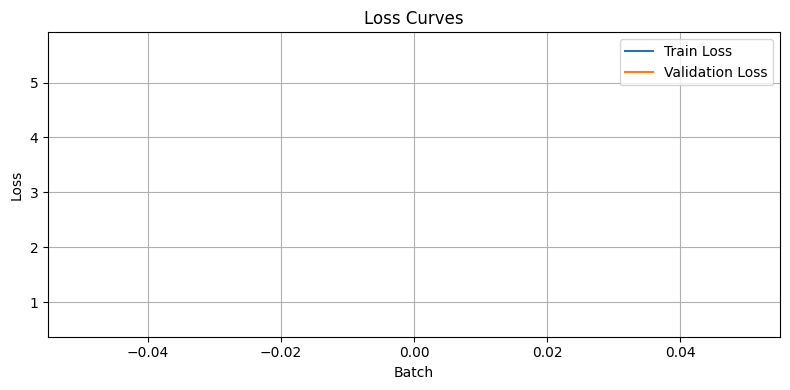

lr=0.3 测试集均方误差损失: nan
开始训练...
[Step 50] Val Loss: 4.2126
[Step 100] Val Loss: 2.9170
[Step 150] Val Loss: 2.1347
[Step 200] Val Loss: 1.6762
Epoch [1/100]  Train Loss: 3.1158
[Step 250] Val Loss: 1.3599
[Step 300] Val Loss: 1.1588
[Step 350] Val Loss: 1.0214
[Step 400] Val Loss: 0.9169
[Step 450] Val Loss: 0.8437
Epoch [2/100]  Train Loss: 1.1171
[Step 500] Val Loss: 0.7897
[Step 550] Val Loss: 0.7487
[Step 600] Val Loss: 0.7213
[Step 650] Val Loss: 0.6982
Epoch [3/100]  Train Loss: 0.7487
[Step 700] Val Loss: 0.6816
[Step 750] Val Loss: 0.6692
[Step 800] Val Loss: 0.6586
[Step 850] Val Loss: 0.6498
[Step 900] Val Loss: 0.6421
Epoch [4/100]  Train Loss: 0.6492
[Step 950] Val Loss: 0.6372
[Step 1000] Val Loss: 0.6327
[Step 1050] Val Loss: 0.6283
[Step 1100] Val Loss: 0.6247
Epoch [5/100]  Train Loss: 0.6164
[Step 1150] Val Loss: 0.6208
[Step 1200] Val Loss: 0.6181
[Step 1250] Val Loss: 0.6156
[Step 1300] Val Loss: 0.6132
[Step 1350] Val Loss: 0.6105
Epoch [6/100]  Train Loss: 0.6008
[St

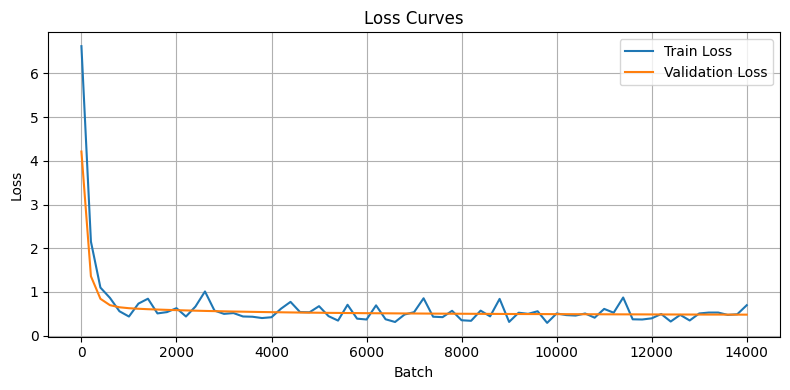

lr=0.001 测试集均方误差损失: 0.4469


In [8]:
# 导入训练相关模块，包括训练器、早停和模型保存
from wangdao_train import Trainer, EarlyStopping, ModelCheckpoint

# 设置训练使用的设备（优先用GPU，没有则用CPU）
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

# 对不同学习率进行遍历实验，实现简单的网格搜索
for lr in [1e-2, 3e-2, 3e-1, 1e-3]:
    # 每次循环都重新实例化模型，防止上一次训练的参数影响当前实验
    model = HousePriceModel(input_size=input_size, hidden_size=30, output_size=1).to(device)
    
    # 初始化损失函数：均方误差MSE，适用于回归任务
    criterion = nn.MSELoss()
    # 初始化优化器：使用SGD（随机梯度下降），学习率由循环参数lr设置
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    
    # 初始化早停机制
    # 当验证集损失多少个周期(patience)未改善，自动停止训练
    early_stopping = EarlyStopping(
        patience=10,      # 容忍10个周期无提升
        min_delta=0.001,  # 若提升低于0.001则认为无提升
        mode='min'        # 用于监控的指标是希望越小越好（最小化val_loss）
    )
    
    # 初始化模型保存检查点
    # 训练过程中自动保存最优模型
    model_checkpoint = ModelCheckpoint(
        filepath='./checkpoints/regression_model_epoch_{epoch}.ckpt', # 保存路径和文件名可动态替换epoch
        monitor='val_loss',        # 监控验证集损失
        save_best_only=True,       # 仅保存效果最好的那一版模型
        mode='min',                # 最小化val_loss为目标
        min_delta=0.001            # 损失改善阈值
    )

    # 创建训练器对象，将模型、数据、损失、优化器、训练超参数等全部交由Trainer管理
    trainer = Trainer(
        model=model,
        train_loader=train_loader,     # 训练集dataloader
        val_loader=val_loader,         # 验证集dataloader
        criterion=criterion,           # 损失函数
        optimizer=optimizer,           # 优化器
        device=device,                 # 使用的设备（CPU或GPU）
        eval_step=50,                  # 每训练50个batch就评估一次验证集
        early_stopping=early_stopping, # 早停机制
        model_checkpoint=model_checkpoint # 模型自动保存
    )

    # 正式开始训练
    print("开始训练...")
    trainer.train_regression(num_epochs=100)  # 最大训练轮数为100轮
    trainer.plot_curves(200)                  # 绘制训练曲线，最多展示200个评估点

    # 在测试集上评估模型性能，计算平均损失
    model.eval()  # 设置为评估模式，关闭dropout/batchnorm等
    test_loss = 0.0        # 测试集总损失累积
    total = 0              # 测试样本总数
    with torch.no_grad():  # 关闭梯度，减少显存占用，加速推理
        for batch in test_loader:
            # 查看targets的类型
    #        print("targets类型:", type(targets), "targets.shape:", targets.shape)
            inputs, targets = batch
            inputs = inputs.to(device)     # 移动到设备上
            targets = targets.to(device)
            outputs = model(inputs)        # 前向传播得到预测值
            loss = criterion(outputs, targets) # 计算该batch损失
            batch_size = inputs.size(0)
            test_loss += loss.item() * batch_size # 损失乘以batch样本数进行加权汇总
            total += batch_size                 # 累计样本数

    avg_test_loss = test_loss / total if total > 0 else 0 # 得到测试集平均损失
    print(f"lr={lr} 测试集均方误差损失: {avg_test_loss:.4f}") # 输出各学习率下的测试结果